# Did the Optuna search find alpha, or overfit the backtest?

A hyperparameter search that maximises in-sample Sharpe will hand you a
great-looking number almost every time. The question is whether that number
survives contact with data the search never saw.

This notebook takes a real BTC/USDT daily series, runs an Optuna search over a
small trading model, and then audits the winner with the tools that answer
that question:

- **PBO** (`probability_of_backtest_overfitting`): how often the
  in-sample-best configuration lands below the median out-of-sample.
- **Deflated Sharpe** (`deflated_sharpe_ratio_full`) with an
  **effective-trial** correction (`effective_n_trials`): TPE trials are
  correlated, so the raw trial count over-deflates the result.
- **Combinatorial backtest paths** (`CombinatorialPurgedCV.backtest_paths` +
  `path_metrics`): the spread of Sharpe across many out-of-sample paths, not a
  single optimistic figure.

Real daily data via `pricehub`, cached under `examples/data/`. Reproducible:
fixed seeds and a seeded TPE sampler. Install with
`pip install purgedcv[examples,optuna]`.

In [1]:
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from purgedcv import (
    CombinatorialPurgedCV,
    deflated_sharpe_ratio_full,
    effective_n_trials,
    path_metrics,
    probability_of_backtest_overfitting,
)
from purgedcv.optuna_integration import TrialSharpeRecorder

optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 0
BARS_PER_YEAR = 252
WARMUP = 60        # rows reserved so every config shares one length
MAX_LOOKBACK = 40  # longest feature window the search may pick
N_TRIALS = 400
TOP_K = 80         # configurations entered into the PBO matrix

## 1. Real BTC/USDT daily data

Downloaded once via `pricehub` and cached; later runs read the local copy and
work offline.

In [2]:
DATA_DIR = Path("data") if Path("data").exists() else Path("examples/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
cache = DATA_DIR / "btcusdt_1d_binance_spot_2021_2023.csv"

if cache.exists():
    raw = pd.read_csv(cache, index_col=0, parse_dates=True)
else:
    from pricehub import get_ohlc

    raw = get_ohlc(
        broker="binance_spot",
        symbol="BTCUSDT",
        interval="1d",
        start="2021-01-01",
        end="2023-09-28",
    )
    raw.to_csv(cache)

close = raw["Close"].astype(float)
log_ret = np.log(close / close.shift(1))
print(f"{len(close)} daily bars, {close.index[0].date()} to {close.index[-1].date()}")

1001 daily bars, 2021-01-01 to 2023-09-28


## 2. A small, tunable model

Three features feed a Ridge model that predicts the next bar's return:
momentum, volatility, and short-term reversal, each over its own window. The
position is the sign of the prediction; the per-bar strategy return is that
position times the realised next-bar return. The search tunes the three
windows and the Ridge penalty `alpha`, four knobs in all, which gives TPE
enough room to chase the in-sample peak.

Every configuration's return series starts at `WARMUP`, so they all share the
same length and can be stacked for PBO.

In [3]:
idx = np.arange(WARMUP, len(close) - 1)  # valid bar positions t (need t+1)
lr = log_ret.to_numpy()
realised_next = lr[idx + 1]              # next-bar return, the label and the payoff
n_obs = idx.size
split = int(0.7 * n_obs)                 # in-sample / out-of-sample boundary


def build_features(w_mom: int, w_vol: int, w_rev: int) -> np.ndarray:
    mom = log_ret.rolling(w_mom).sum().to_numpy()[idx]
    vol = log_ret.rolling(w_vol).std().to_numpy()[idx]
    rev = (-log_ret.rolling(w_rev).sum()).to_numpy()[idx]
    return np.column_stack([mom, vol, rev])


def config_returns(w_mom: int, w_vol: int, w_rev: int, alpha: float) -> np.ndarray:
    # Per-bar strategy log-returns for one configuration.
    features = build_features(w_mom, w_vol, w_rev)
    model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    model.fit(features, realised_next)   # in-sample fit: exactly the overfit setup
    position = np.sign(model.predict(features))
    return position * realised_next


def per_bar_sharpe(returns: np.ndarray) -> float:
    std = returns.std(ddof=1)
    return float(returns.mean() / std) if std > 0 else 0.0


print(f"{n_obs} usable bars; in-sample {split}, out-of-sample {n_obs - split}")

940 usable bars; in-sample 658, out-of-sample 282


## 3. The Optuna search

A seeded TPE sampler maximises the in-sample Sharpe. `TrialSharpeRecorder`
collects each trial's Sharpe (recorded **annualised**, the convention most
dashboards use). Every trial's full return series is kept for the audit.

In [4]:
trial_returns: dict[int, np.ndarray] = {}
trial_params: dict[int, dict] = {}
recorder = TrialSharpeRecorder()


def objective(trial: optuna.Trial) -> float:
    params = {
        "w_mom": trial.suggest_int("w_mom", 2, MAX_LOOKBACK),
        "w_vol": trial.suggest_int("w_vol", 2, MAX_LOOKBACK),
        "w_rev": trial.suggest_int("w_rev", 2, MAX_LOOKBACK),
        "alpha": trial.suggest_float("alpha", 1e-3, 1e3, log=True),
    }
    returns = config_returns(**params)
    trial_returns[trial.number] = returns
    trial_params[trial.number] = params
    is_sharpe = per_bar_sharpe(returns[:split])
    trial.set_user_attr("sharpe", is_sharpe * np.sqrt(BARS_PER_YEAR))  # annualised
    return is_sharpe


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=N_TRIALS, callbacks=[recorder])

champion = study.best_trial.number
champ_is_sharpe_ann = study.best_value * np.sqrt(BARS_PER_YEAR)
print(f"champion config         : {trial_params[champion]}")
print(f"in-sample Sharpe (ann.) : {champ_is_sharpe_ann:+.2f}")

champion config         : {'w_mom': 23, 'w_vol': 13, 'w_rev': 28, 'alpha': 4.593746191801426}
in-sample Sharpe (ann.) : +2.48


That in-sample Sharpe looks like a deployable strategy. The rest of the
notebook asks whether it is one.

## 4. Probability of backtest overfitting

Stack the top configurations into an `(n_configs, n_obs)` matrix and run PBO.
A PBO above 0.5 with a negative degradation slope is the warning sign:
picking the in-sample best is then no better than a coin flip for the
out-of-sample rank, so in-sample strength carries little into the future.

In [5]:
ranked = sorted(trial_returns, key=lambda n: per_bar_sharpe(trial_returns[n][:split]), reverse=True)
chosen = ranked[:TOP_K]
matrix = np.vstack([trial_returns[n] for n in chosen])  # (TOP_K, n_obs)

pbo = probability_of_backtest_overfitting(matrix, n_splits=12)
print(f"configurations  : {matrix.shape[0]}")
print(f"CSCV combos     : {pbo.n_combos}")
print(f"PBO             : {pbo.pbo:.2f}   (0 = no overfit, 0.5 = chance, 1 = always worst)")
print(f"degradation slope: {pbo.slope:+.2f}   (< 0 = in-sample best tends to be out-of-sample poor)")

configurations  : 80
CSCV combos     : 924
PBO             : 0.55   (0 = no overfit, 0.5 = chance, 1 = always worst)
degradation slope: -0.59   (< 0 = in-sample best tends to be out-of-sample poor)


## 5. Deflated Sharpe: raw vs effective trial count

The champion is judged on its **held-out** half. The deflated Sharpe discounts
the observed Sharpe by how many configurations were tried. Feeding the raw
trial count assumes every trial was an independent bet. TPE is not independent:
it concentrates around the regions that looked good, so consecutive trials are
correlated. `effective_n_trials` reads that off the trial-Sharpe series and
returns the count that actually matters.

`var_sharpe` was recorded annualised, so `bars_per_year` converts it to the
per-bar units the deflation needs.

In [6]:
champ_oos = trial_returns[champion][split:]
var_ann = recorder.var_sharpe()       # annualised, as recorded
n_eff = effective_n_trials(recorder.sharpes())  # recorder.n_effective() is the shortcut

naive = deflated_sharpe_ratio_full(
    champ_oos, n_trials=recorder.n_trials(), var_sharpe=var_ann, bars_per_year=BARS_PER_YEAR
)
corrected = deflated_sharpe_ratio_full(
    champ_oos, n_trials=n_eff, var_sharpe=var_ann, bars_per_year=BARS_PER_YEAR
)

print(f"out-of-sample Sharpe (per bar): {naive.observed_sr:+.4f}")
print(f"raw trials {recorder.n_trials():>4}  -> sr_star {naive.sr_star:+.3f}  DSR {naive.dsr:.4f}")
print(f"effective  {n_eff:>4}  -> sr_star {corrected.sr_star:+.3f}  DSR {corrected.dsr:.4f}")

out-of-sample Sharpe (per bar): +0.0198
raw trials  400  -> sr_star +0.095  DSR 0.1036
effective    25  -> sr_star +0.064  DSR 0.2314


## 6. The champion across combinatorial backtest paths

A single out-of-sample number is itself one draw. `CombinatorialPurgedCV`
refits the champion model across many purged train/test partitions and
`path_metrics` summarises every reconstructed path. The spread, not the best
path, is the honest picture.

In [7]:
champ = trial_params[champion]
X = build_features(champ["w_mom"], champ["w_vol"], champ["w_rev"])
y = realised_next
pred_times = pd.Series(close.index[idx])
eval_times = pred_times + pd.Timedelta(days=1)

cv = CombinatorialPurgedCV(
    n_splits=8,
    n_test_groups=2,
    prediction_times=pred_times,
    evaluation_times=eval_times,
    purge_horizon="1D",
)
model = make_pipeline(StandardScaler(), Ridge(alpha=champ["alpha"]))
pred_paths = cv.backtest_paths(model, X, y)
strat_paths = np.sign(pred_paths) * y[np.newaxis, :]

paths_table = path_metrics(strat_paths, bars_per_year=BARS_PER_YEAR)
print(paths_table.round(2).to_string())
print()
print(
    f"path Sharpe  median {paths_table['sharpe'].median():+.2f}"
    f"   worst {paths_table['sharpe'].min():+.2f}   best {paths_table['sharpe'].max():+.2f}"
)

      sharpe  calmar  max_drawdown  total_return
path                                            
0       0.95    1.07          0.47          1.86
1       1.29    1.36          0.50          2.54
2       1.01    1.05          0.50          1.98
3       1.62    1.87          0.45          3.16
4       1.35    1.25          0.57          2.64
5       1.64    1.92          0.45          3.20
6       1.55    1.44          0.56          3.02

path Sharpe  median +1.35   worst +0.95   best +1.64


## 7. The picture

Four views of the same search.

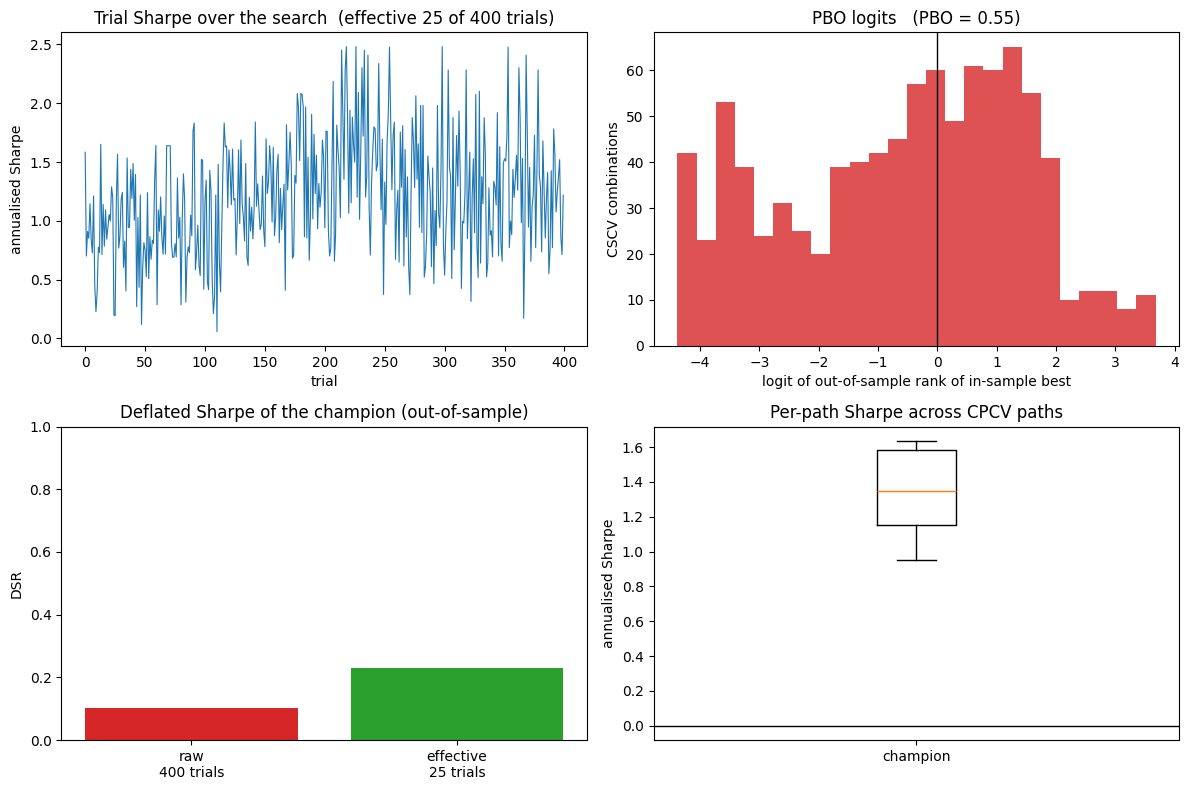

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (a) Trial-Sharpe trajectory: TPE trials concentrate, they are not independent.
axes[0, 0].plot(recorder.sharpes(), linewidth=0.8, color="#1f77b4")
axes[0, 0].set_title(f"Trial Sharpe over the search  (effective {n_eff} of {recorder.n_trials()} trials)")
axes[0, 0].set_xlabel("trial")
axes[0, 0].set_ylabel("annualised Sharpe")

# (b) PBO logit distribution: mass below 0 is the overfit fraction.
axes[0, 1].hist(pbo.logits, bins=25, color="#d62728", alpha=0.8)
axes[0, 1].axvline(0.0, color="black", linewidth=1)
axes[0, 1].set_title(f"PBO logits   (PBO = {pbo.pbo:.2f})")
axes[0, 1].set_xlabel("logit of out-of-sample rank of in-sample best")
axes[0, 1].set_ylabel("CSCV combinations")

# (c) Deflated Sharpe, raw vs effective trial count.
axes[1, 0].bar(
    [f"raw\n{recorder.n_trials()} trials", f"effective\n{n_eff} trials"],
    [naive.dsr, corrected.dsr],
    color=["#d62728", "#2ca02c"],
)
axes[1, 0].set_title("Deflated Sharpe of the champion (out-of-sample)")
axes[1, 0].set_ylabel("DSR")
axes[1, 0].set_ylim(0, 1)

# (d) Distribution of Sharpe across backtest paths.
axes[1, 1].boxplot(paths_table["sharpe"].dropna(), vert=True)
axes[1, 1].axhline(0.0, color="black", linewidth=1)
axes[1, 1].set_title("Per-path Sharpe across CPCV paths")
axes[1, 1].set_ylabel("annualised Sharpe")
axes[1, 1].set_xticklabels(["champion"])

plt.tight_layout()
plt.show()

## Reading the verdict

The tools tell a layered story rather than a single yes or no.

The combinatorial paths (section 6) are all positive, around 1.3 Sharpe: the
momentum-and-reversal model family does carry genuine out-of-sample structure
on 2021-2023 BTC, which trended hard. This is not a no-edge market where
everything is noise.

But the audit still flags the search. PBO sits at 0.55 with a negative slope:
among 80 near-tied configurations, picking the in-sample best is barely better
than a coin flip for out-of-sample rank, so the specific champion was not
reliably identified. The deflated Sharpe, judged on held-out data and
discounted for the search, is modest: 0.10 under the raw 400-trial count,
rising to 0.23 once `effective_n_trials` recognises the 400 TPE trials were
really about 25 independent bets.

The honest read: there is a real effect here, but the hyperparameter search did
not isolate a uniquely good champion, and the evidence after deflation is weak.
Treat the winner as one of many similar configurations, not a special
discovery. That distinction, easy to miss from the in-sample Sharpe of +2.5
alone, is what these tools exist to surface.